# 6. Analysis of Payments and Products:
6.1. Study the distribution of payment methods and assess their influence on the likelihood of successful deal closure.
6.2. Evaluate the popularity and effectiveness of different products and educational program types in terms of conversion and revenue performance.

Loading the necessary libraries, loading the deals_clean file

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_deals = pd.read_pickle("../processed/Deals_clean.pkl")
df_deals.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
0,5805028000056864695,Ben Hall,NaT,NaN,New Lead,NaN,03.07.23women,NaT,v16,women,...,2024-06-21 15:30:00,NaN,NaN,NaN,NaN,5805028000056849495,NaN,<NA>,Unknown,<NA>
1,5805028000056859489,Ulysses Adams,NaT,NaN,New Lead,NaN,Unknown,NaT,NaN,NaN,...,2024-06-21 15:23:00,6.0,NaN,0.0,2000.0,5805028000056834471,NaN,<NA>,Unknown,<NA>
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,engwien_AT,0 days 00:26:43,b1-at,21_06_2024,...,2024-06-21 00:00:00,NaN,NaN,NaN,NaN,5805028000056854421,NaN,<NA>,10-30 min,<NA>


6.1. Study the distribution of payment methods and assess their influence on the likelihood of successful deal closure.

Step 1. Filter data by two conditions. 

In [3]:
df_deals_success = df_deals[
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] >= 10)
]
df_deals_success

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
468,5805028000055502703,Eva Kent,2024-06-18,B - Medium,Payment Done,NaN,performancemax_wide_AT,0 days 14:35:20,_{region_name}_,NaN,...,2024-06-15 20:01:00,11.0,1.0,500.0,4500.0,5805028000055471387,Podskalie,<NA>,12 - 24h,<NA>
478,5805028000055524315,Ben Hall,2024-06-19,A - High,Payment Done,NaN,12.07.2023wide_DE,0 days 00:17:25,bloggersvideo11,wide,...,2024-06-15 17:02:00,11.0,1.0,500.0,4500.0,5805028000055503302,Zinnowitz,<NA>,10-30 min,<NA>
497,5805028000055524040,Ben Hall,2024-06-30,B - Medium,Payment Done,NaN,Live_DE,0 days 00:23:42,b0,03_06_2024,...,2024-06-15 12:20:00,6.0,1.0,1000.0,9000.0,5805028000055464156,Wolfsburg,B1,10-30 min,B1
833,5805028000054664018,Ben Hall,2024-06-26,D - Non Target,Payment Done,NaN,Unknown,0 days 16:31:52,NaN,NaN,...,2024-06-11 19:39:00,6.0,1.0,1000.0,9000.0,5805028000054683001,Zwickau,A2,12 - 24h,A2
1040,5805028000054257317,Quincy Vincent,2024-06-17,B - Medium,Payment Done,NaN,02.07.23wide_DE,0 days 00:45:55,bloggersvideo16com,wide,...,2024-06-10 15:33:00,11.0,1.0,1000.0,11000.0,5805028000054284461,Leinfelden-Echterdingen,B1,30 min - 1h,B1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21314,5805028000002302112,Julia Nelson,2023-07-19,C - Low,Payment Done,Expensive,performancemax_digitalmarkt_ru_DE,0 days 15:24:52,_{region_name}_,NaN,...,2023-07-18 21:11:00,6.0,2.0,1000.0,5000.0,5805028000002302109,Wolfsburg,b1,12 - 24h,B1
21367,5805028000001987082,Julia Nelson,2023-07-17,C - Low,Payment Done,Conditions are not suitable,12.07.2023wide_DE,0 days 00:49:16,v3com,wide,...,2023-07-17 00:00:00,11.0,11.0,1000.0,11000.0,5805028000001986077,-,b1 должна получить результаты в феврале,30 min - 1h,B1
21410,5805028000001885076,Jane Smith,2023-08-31,A - High,Payment Done,NaN,04.07.23recentlymoved_DE,0 days 00:13:31,b2,recentlymoved,...,2023-07-15 13:27:00,11.0,11.0,450.0,4000.0,5805028000001880249,Ingolstadt,<NA>,10-30 min,<NA>
21555,5805028000001401001,Oliver Taylor,2023-07-22,B - Medium,Payment Done,NaN,02.07.23wide_DE,0 days 02:22:36,b3,wide,...,2023-07-08 08:56:00,11.0,8.0,1000.0,11500.0,5805028000001350049,NaN,<NA>,1.5 - 3h,<NA>


Step 2. Calculate payment type distribution for filtered successful deals.

In [4]:
payment_type_distribution = (
    df_deals_success["Payment Type"]
    .value_counts()
    .reset_index()
    )
payment_type_distribution

,Payment Type,count
0,Recurring Payments,250
1,One Payment,110
2,Reservation,1


Step 3. Create Payment Type distribution table for paid deals. Analyse only those transaction for which we have information

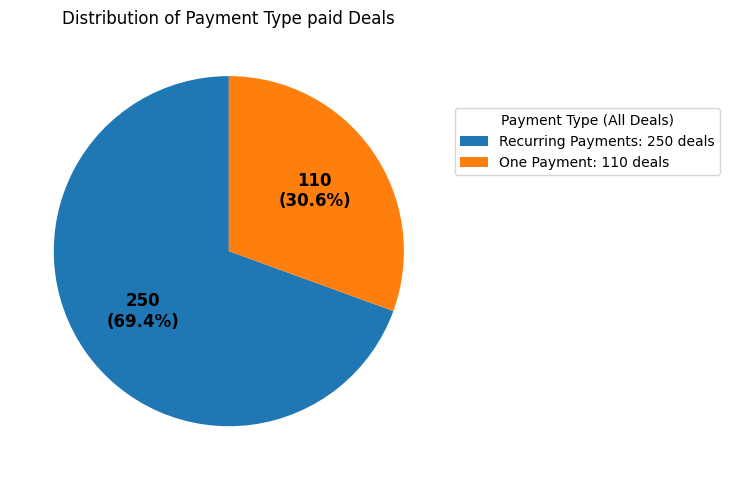

In [5]:
payment_type_distribution = (
    df_deals_success["Payment Type"]
    .value_counts()
    .reset_index()
)
pt_plot = payment_type_distribution[
    payment_type_distribution["Payment Type"].isin(
        ["Recurring Payments", "One Payment"])].copy()

values = pt_plot["count"]
labels = pt_plot["Payment Type"]

percentages = (values / values.sum() * 100).round(1)

plt.figure(figsize=(7, 6))
wedges, texts, autotexts = plt.pie(
    values,
    labels=None,          
    autopct=lambda pct: f"{int(round(pct/100 * values.sum()))}\n({pct:.1f}%)",
    startangle=90,
    textprops={"color": "black", "fontsize": 12, "ha": "center"}
)

for autotext in autotexts:  
    autotext.set_color("black")
    autotext.set_weight("bold")

legend_labels = [
    f"{l}: {v} deals"
    for l, v, in zip(labels, values)
]
plt.legend(
    wedges,
    legend_labels,
    title="Payment Type (All Deals)",
    loc="center left",
    bbox_to_anchor=(1, 0.75)
)
plt.title("Distribution of Payment Type paid Deals")
plt.tight_layout()
plt.show()

Conclusion:

Data Quality Check
To conclude this section, we filter the dataset to highlight specific examples of incomplete or inconsistent data entry in the CRM system. This demonstrates the need for stricter validation rules.

Distribution in all Deals

In [6]:
payment_type = (
    df_deals["Payment Type"]
    .value_counts()
    .reset_index()
    )
payment_type

,Payment Type,count
0,Recurring Payments,350
1,One Payment,141
2,Reservation,5


Number of deals where Payment Type is set, but Stage is not 'Payment Done'

In [7]:
df_deals[
    df_deals["Payment Type"].notna() & 
    (df_deals["Stage"] != "Payment Done")
]["Payment Type"].value_counts()

Payment Type
Recurring Payments    100
One Payment            28
Reservation             4
Name: count, dtype: int64

Paid Deals with Missing Payment Type

In [8]:
df_deals[
    (df_deals["Stage"] == "Payment Done") & 
    (df_deals["Payment Type"].isna())
].shape[0]

494

Conclusion

Recurring Payments (250 deals or 69.4%):
Share of clients who chose subscription/installment plans
Predictable cash flow, lower churn risk, as subscription clients rarely leave
One Payment (110 deals or 30.6%):
Share of clients who paid the full amount for training upfront
Fast cash inflow, but lower long-term retention
Since Recurring Payments dominate:
Managers effectively sell the value of long-term cooperation
Recommended: develop loyalty programs to retain these clients
You can forecast stable monthly recurring revenue (MRR).

Recommendations:

Set up automatic synchronization between the payment system and CRM.
Implement mandatory validation: a deal cannot transition to "Payment Done" without a confirmed payment.
Add a "Time to Payment" metric: track how much time passes from lead generation to payment — this will help identify bottlenecks at various stages.
Conduct an audit of "stuck" payments: identify deals where payment has been received but the status has not been updated.
Key Insight: The significant gap between the number of leads and paid deals indicates not only sales process issues but also potential gaps in record-keeping. Successful analytics require clean data: if a payment exists, the deal must be marked as closed.

6.2. Evaluate the popularity and effectiveness of different products and educational program types in terms of conversion and revenue performance.

Step 1 Aggregate deals by product. Product Popularity Analysis.

In [9]:
stage_grouped_count = (
    df_deals.groupby("Product")
    .size()
    .reset_index(name="Product Count")
    .sort_values("Product Count", ascending=False))
stage_grouped_count 

,Product,Product Count
1,Digital Marketing,1990
3,UX/UI Design,1022
4,Web Developer,575
2,Find yourself in IT,4
0,Data Analytics,1


Step 2. Key Product Performance. Filter selected products.

In [10]:
Products = [
    "Digital Marketing", 
    "UX/UI Design", 
    "Web Developer", 
    "Find yourself in IT", 
    "Data Analytics"
]
df_filtered = stage_grouped_count[
    stage_grouped_count["Product"].isin(Products)
].sort_values("Product Count", ascending=False)

df_filtered

,Product,Product Count
1,Digital Marketing,1990
3,UX/UI Design,1022
4,Web Developer,575
2,Find yourself in IT,4
0,Data Analytics,1


Step 3. Calculate successful deals per product

In [11]:
success_by_product = (
    df_deals[
        (df_deals["Stage"] == "Payment Done") &
        (df_deals["Initial Amount Paid"] >= 10)
    ]
    .groupby("Product")
    .size()
    .reset_index(name="success_deals")
)

df_product_deals = df_filtered.merge(success_by_product, on="Product", how="left")
df_product_deals["success_deals"] = df_product_deals["success_deals"].fillna(0).astype(int)

df_product_deals = df_product_deals.rename(columns={"Product Count": "total_deals"})
df_product_deals

,Product,total_deals,success_deals
0,Digital Marketing,1990,473
1,UX/UI Design,1022,229
2,Web Developer,575,137
3,Find yourself in IT,4,0
4,Data Analytics,1,0


Step 4. Calculate failed deals

In [12]:
df_product_deals["failed_deals"] = df_product_deals["total_deals"] - df_product_deals["success_deals"]
df_product_deals[["Product", "total_deals", "success_deals", "failed_deals"]]

,Product,total_deals,success_deals,failed_deals
0,Digital Marketing,1990,473,1517
1,UX/UI Design,1022,229,793
2,Web Developer,575,137,438
3,Find yourself in IT,4,0,4
4,Data Analytics,1,0,1


In [13]:
df_product_deals.to_parquet(
    "../processed/parquet/6_product_deals.parquet", 
    index=False
)

Step 5 Visualisation. Product Performance: Successful vs Unsuccessful Deals

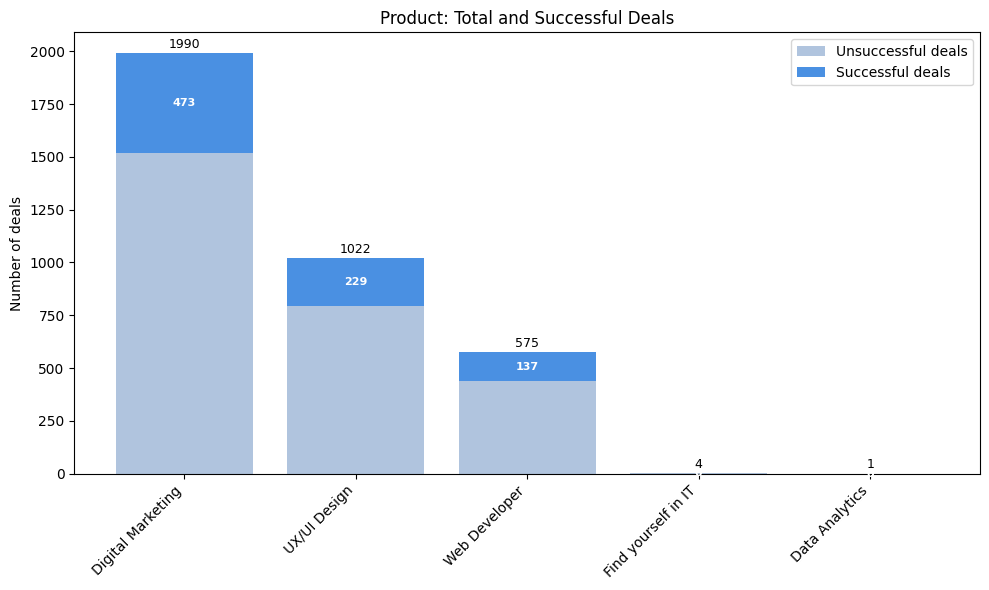

In [14]:
x = np.arange(len(df_product_deals))
fig, ax = plt.subplots(figsize=(10, 6))

bars_failed = ax.bar(
    x,
    df_product_deals["failed_deals"],
    label="Unsuccessful deals",
    color="#B0C4DE"
)
bars_success = ax.bar(
    x,
    df_product_deals["success_deals"],  
    bottom=df_product_deals["failed_deals"],
    label="Successful deals",
    color="#4A90E2"
)

ax.set_xticks(x)
ax.set_xticklabels(df_product_deals["Product"], rotation=45, ha="right")

ax.set_ylabel("Number of deals")
ax.set_title("Product: Total and Successful Deals")
ax.legend()

for i, (total, success, failed) in enumerate(
    zip(df_product_deals["total_deals"], df_product_deals["success_deals"], df_product_deals["failed_deals"])
):
    ax.text(
        x[i],
        failed + success + 10,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=9
    )
    ax.text(
        x[i],
        failed + success / 2,
        str(int(success)),
        ha="center",
        va="center",
        fontsize=8,
        color="white",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

Step 6. Flagship products analyses.

In [15]:
flagship_products = ["Digital Marketing", "UX/UI Design", "Web Developer"]

df_flagship = df_product_deals[
    df_product_deals["Product"].isin(flagship_products)
].copy()
df_flagship

,Product,total_deals,success_deals,failed_deals
0,Digital Marketing,1990,473,1517
1,UX/UI Design,1022,229,793
2,Web Developer,575,137,438


Step 7. Calculate aggregate metrics for the three flagship products, including total, successful, and unsuccessful deals, then derive the overall conversion rate.

In [16]:
total_deals_flagship = df_flagship["total_deals"].sum()
success_deals_flagship = df_flagship["success_deals"].sum()
failed_deals_flagship = df_flagship["failed_deals"].sum()

conversion_rate_flagship = round(success_deals_flagship / total_deals_flagship * 100, 2)

print(f"Products: {', '.join(flagship_products)}")
print(f"Total deals: {total_deals_flagship}")
print(f"Successful: {success_deals_flagship}")
print(f"Unsuccessful: {failed_deals_flagship}")
print(f"Conversion rate: {conversion_rate_flagship}%")

Products: Digital Marketing, UX/UI Design, Web Developer
Total deals: 3587
Successful: 839
Unsuccessful: 2748
Conversion rate: 23.39%


Step 8. AVERAGE CHECK (based on successful deals from df_deals)

In [17]:
df_success_flagship = df_deals[
    (df_deals["Product"].isin(flagship_products)) &
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] >= 100)
]

if len(df_success_flagship) > 0:
    average_check = round(df_success_flagship["Initial Amount Paid"].mean(), 2)
    median_check = round(df_success_flagship["Initial Amount Paid"].median(), 2)
    print(f"\nAverage check: {average_check:,.2f} ")
    print(f"Median check: {median_check:,.2f} ")
else:
    average_check = 0
    median_check = 0
    print("\nNo successful deals to calculate average check")



Average check: 1,132.72 
Median check: 1,000.00 


Step 9 Results by Product

In [18]:
for idx, row in df_flagship.iterrows():
    product_name = row["Product"]
    total = row["total_deals"]
    success = row["success_deals"]
    failed = row["failed_deals"]
    conv_rate = round(success / total * 100, 1) if total > 0 else 0
    
    print(f"\n{product_name}:")
    print(f"  Total: {total} | Successful: {success} | Unsuccessful: {failed}")
    print(f"  Conversion rate: {conv_rate}%")


Digital Marketing:
  Total: 1990 | Successful: 473 | Unsuccessful: 1517
  Conversion rate: 23.8%

UX/UI Design:
  Total: 1022 | Successful: 229 | Unsuccessful: 793
  Conversion rate: 22.4%

Web Developer:
  Total: 575 | Successful: 137 | Unsuccessful: 438
  Conversion rate: 23.8%


Step 9. Estimate program cost range based on successful payments

In [19]:
df_success_flagship = df_deals[
    (df_deals["Product"].isin(flagship_products)) &
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] >= 10)
]

if len(df_success_flagship) > 0:
    q1 = df_success_flagship["Initial Amount Paid"].quantile(0.25)
    q3 = df_success_flagship["Initial Amount Paid"].quantile(0.75)
    print(f"Estimated program cost range: {q1:,.0f} — {q3:,.0f}")

Estimated program cost range: 500 — 1,000


In [20]:
print(f"1. Three products generate {total_deals_flagship} deals")
print(f"2. Average conversion rate: {conversion_rate_flagship}%")
print(f"3. Average check: ~{average_check:,.0f}")
print(f"4. Conversion rate is stable across all products (22-24%)")

1. Three products generate 3587 deals
2. Average conversion rate: 23.39%
3. Average check: ~1,133
4. Conversion rate is stable across all products (22-24%)


# Conclusion
Three Key Flagship Products
Digital Marketing, UX/UI Design, Web Developer
Drive the entire real sales funnel: 3,587 deals combined
Stable and consistent conversion rate: 22–24%
Average check: 1,133
Average program cost: 5,000 — 10,000 
User behavior patterns are similar across all three directions
These are the company's three most stable and high-converting products.

6.3 Training Types Analysis

Step 1 Explore all Education Type categories and Successful Deals by Education Type.

In [21]:
education_type_all = (
    df_deals["Education Type"]
    .value_counts()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)
education_type_all

,Education Type,Count
0,Morning,2895
1,Evening,404


In [22]:
success_by_educational = (
    df_deals[
        (df_deals["Stage"] == "Payment Done") &
        (df_deals["Initial Amount Paid"] >= 100)
    ]
    .groupby("Education Type")
    .size()
    .reset_index(name="success_deals")
    .sort_values("success_deals", ascending=False)
)
success_by_educational

,Education Type,success_deals
1,Morning,661
0,Evening,171


Step 3. Diagramma/Pie chart Distribution of Morning vs Evening Successful deals/students only

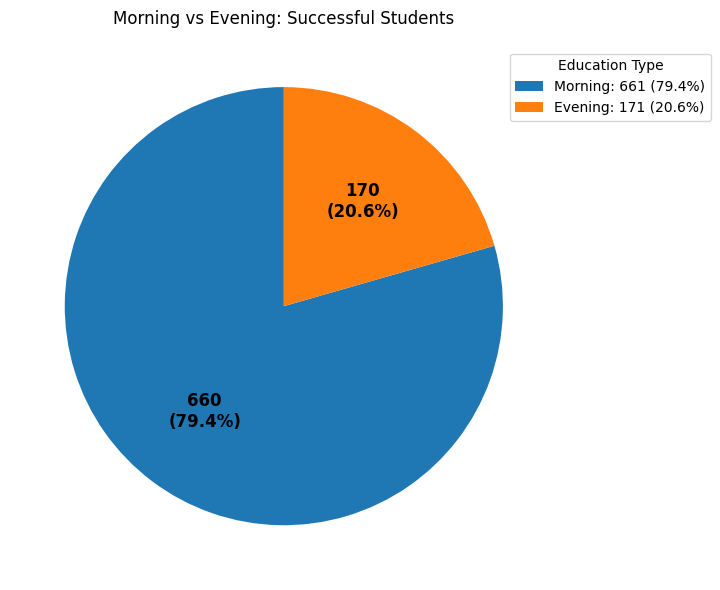

In [23]:
values = success_by_educational["success_deals"].values
labels = success_by_educational["Education Type"].values

plt.figure(figsize=(7, 6))
wedges, _, autotexts = plt.pie(
    values, labels=None, startangle=90,
    autopct=lambda p: f"{int(p*sum(values)/100)}\n({p:.1f}%)",
    textprops={"color": "black", "fontsize": 12, "weight": "bold"}
)

plt.legend(wedges, [f"{l}: {v} ({v/sum(values)*100:.1f}%)" for l, v in zip(labels, values)], 
           title="Education Type", loc="center left", bbox_to_anchor=(0.9, 0.9))
plt.title("Morning vs Evening: Successful Students")
plt.tight_layout()
plt.show()

Conclusion
Evening groups convert two times better (42% vs 23%), but Morning brings three times more revenue per deal. Critical issue: 18,294 deals in "Not selected" with 0.14% conversion — the biggest growth opportunity.

Merge total and successful deals to calculate conversion

In [24]:
education_total = (
    df_deals["Education Type"]
    .value_counts()
    .reset_index(name="total_deals")
    .sort_values("total_deals", ascending=False)
)
education_analysis = education_total.merge(
    success_by_educational, on="Education Type", how="left"
)
education_analysis["success_deals"] = education_analysis["success_deals"].fillna(0)
education_analysis["conversion_rate"] = (
    education_analysis["success_deals"] / education_analysis["total_deals"] * 100
).round(2)
education_analysis

,Education Type,total_deals,success_deals,conversion_rate
0,Morning,2895,661,22.83
1,Evening,404,171,42.33


 Step 4. Quick summary: Education Type performance

In [25]:
median_payment = (
    df_deals[
        (df_deals["Stage"] == "Payment Done") &
        (df_deals["Initial Amount Paid"] >= 100)
    ]
    .groupby("Education Type")["Initial Amount Paid"]
    .median()
    .reset_index(name="median_payment")
)
result = education_analysis.merge(median_payment, on="Education Type", how="left")
print(result[["Education Type", "total_deals", "success_deals", "conversion_rate", "median_payment"]].to_string(index=False))

Education Type  total_deals  success_deals  conversion_rate  median_payment
       Morning         2895            661            22.83          1000.0
       Evening          404            171            42.33           350.0
